# Aprendizado Estatístico

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (10.0, 8.0)
print("Ambiente configurado")

Ambiente configurado


## Gradiente

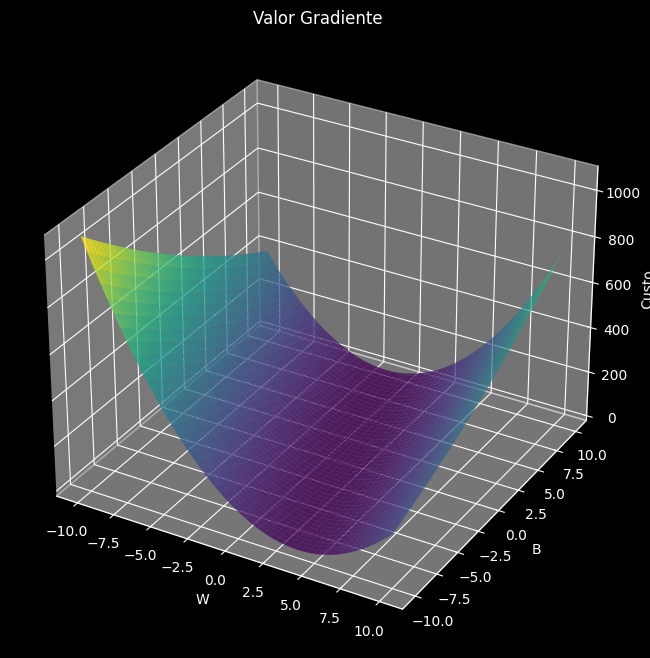

In [2]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

def compute_cost(w, b, x, y):
    m = len(y)
    predictions = w * x + b
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

w_vals = np.linspace(-10, 10, 100)
b_vals = np.linspace(-10, 10, 100)
W, B = np.meshgrid(w_vals, b_vals)
J_vals = np.array([compute_cost(w, b, x, y) for w, b in zip(np.ravel(W), np.ravel(B))])
J_vals = J_vals.reshape(W.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J_vals, cmap='viridis', alpha=0.8)
ax.set_xlabel('W')
ax.set_ylabel('B')
ax.set_zlabel('Custo')
ax.set_title('Valor Gradiente')
plt.show()

## SVM (Support Vector Machine)

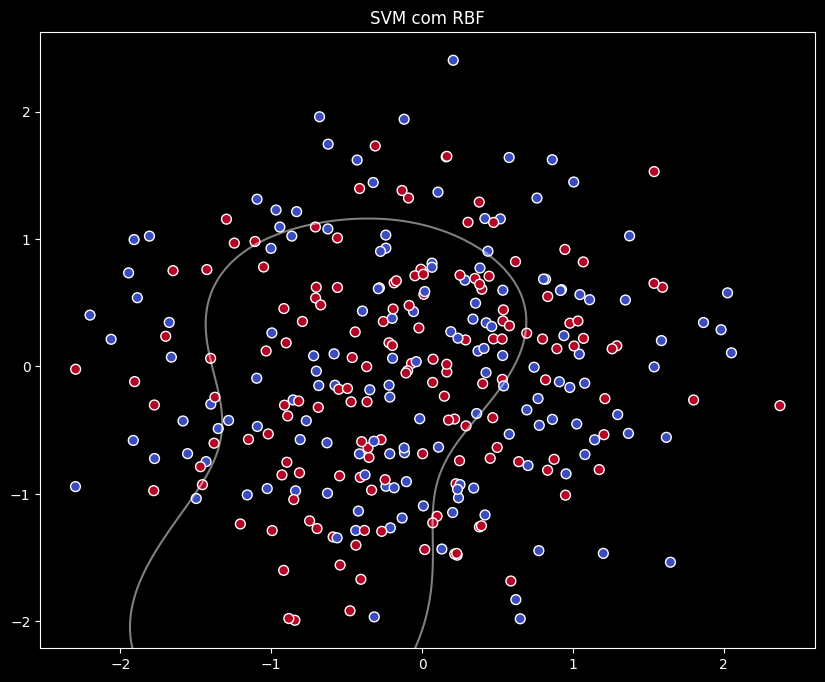

In [3]:
x_circ, y_circ = make_circles(n_samples=300, noise=0.6, factor=0.8, random_state=0)

svm = SVC(kernel='rbf', C=1.0)
svm.fit(x_circ, y_circ)

plt.figure(figsize=(10, 8))
plt.scatter(x_circ[:, 0], x_circ[:, 1], c=y_circ, s=50, cmap='coolwarm', edgecolors='w')

ax = plt.gca()
xlim, ylim = ax.get_xlim(), ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contour(xx, yy, Z, colors='w', levels=[0], alpha=0.5, linestyles='-')
plt.title('SVM com RBF')
plt.show()


## Matriz de confusão

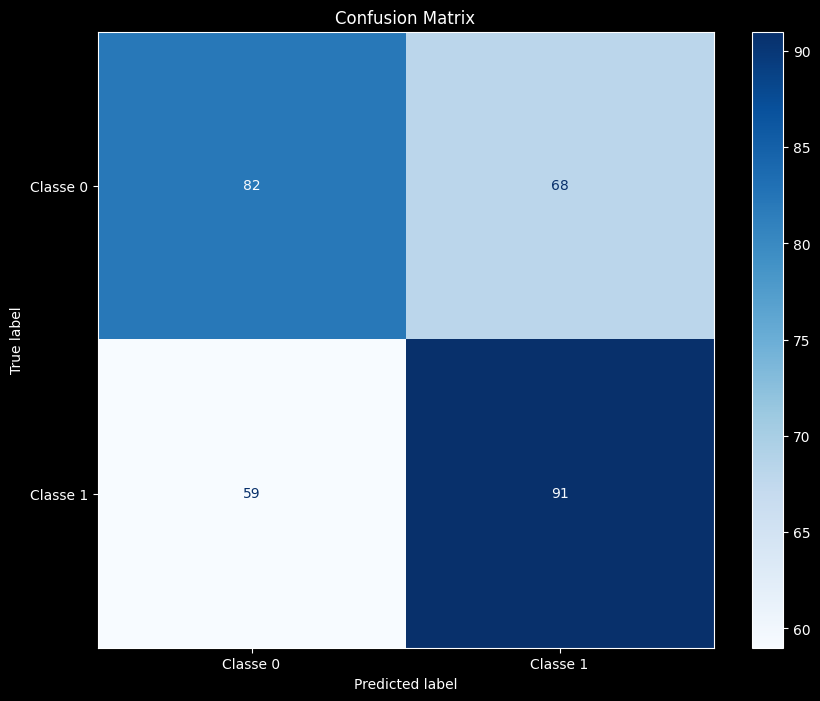

Relatório de classificacao
              precision    recall  f1-score   support

           0       0.58      0.55      0.56       150
           1       0.57      0.61      0.59       150

    accuracy                           0.58       300
   macro avg       0.58      0.58      0.58       300
weighted avg       0.58      0.58      0.58       300



In [4]:
y_predict = svm.predict(x_circ)

cm = confusion_matrix(y_circ, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print("Relatório de classificacao")
print(classification_report(y_circ, y_predict))